
Random Forest
Accuracy: 0.9500

Confusion Matrix:
[[20  0  0]
 [ 0 20  0]
 [ 2  1 17]]

Classification Report:
              precision    recall  f1-score   support

    Aloevera       0.91      1.00      0.95        20
        Amla       0.95      1.00      0.98        20
       Giloy       1.00      0.85      0.92        20

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60


Logistic Regression
Accuracy: 0.7833

Confusion Matrix:
[[20  0  0]
 [ 0 20  0]
 [12  1  7]]

Classification Report:
              precision    recall  f1-score   support

    Aloevera       0.62      1.00      0.77        20
        Amla       0.95      1.00      0.98        20
       Giloy       1.00      0.35      0.52        20

    accuracy                           0.78        60
   macro avg       0.86      0.78      0.75        60
weighted avg       0.86      0.78      0.75        60


SVM
Acc

c:\Users\vishw\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\vishw\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:189: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


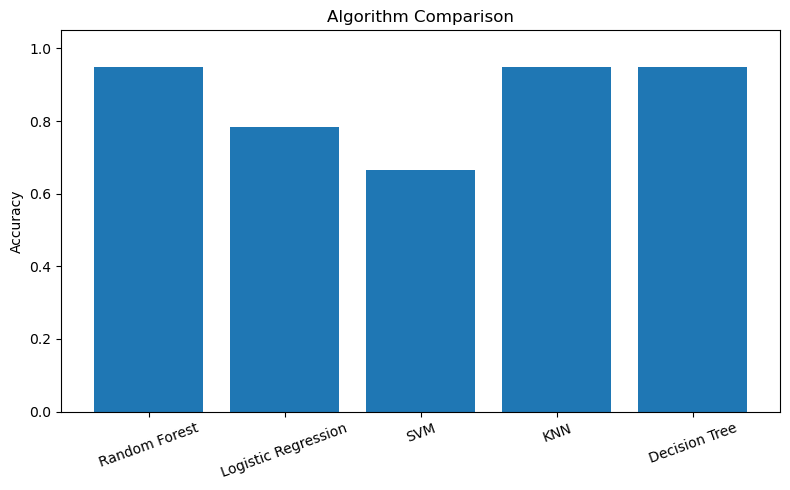

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

DF = pd.read_csv("real_dravya_dataset.csv")

X = DF[["pH", "TDS", "EC"]]
y = DF["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

accuracies = {}
best_model = None
best_accuracy = 0
best_name = ""

for name, model in models.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    print(f"Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_name = name

joblib.dump(best_model, "best_dravya_model.pkl")

print("\n" + "=" * 60)
print(f"Best Model: {best_name}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print("Saved as best_dravya_model.pkl")
print("=" * 60)

plt.figure(figsize=(8, 5))
plt.bar(list(accuracies.keys()), list(accuracies.values()))
plt.title("Algorithm Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("algorithm_comparison.png", dpi=300)
plt.show()